In [1]:
import MDAnalysis as mda
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
from MDAnalysis.lib.nsgrid import FastNS
from MDAnalysis.lib import mdamath 
from collections import defaultdict
from scipy.spatial import cKDTree
import math
import os
import matplotlib.pyplot as plt

lammps_data = 'lammps.data'
trajectory_file = 'traj.lammpstrj'
u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')


/home/user/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [2]:

total_chains = 600              # Set to actual polymer chain count in your system
polymer_typeA = 1                # Atom type for polymer
polymer_typeB = 2 
receptor_typeC = 3               # Atom type for receptor
receptor_typeD = 4

num_bins = 50
max_distance = 50               # Maximum distance sphere radius (Angstrom)
bins = np.linspace(0, max_distance, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

z_slab = 115.0                  # z where slab starts t(set for your system)
buffer = 0.0   
# Slab region definition
x_min, x_max = -40, 40
y_min, y_max = -40, 40
z_min, z_max = 32.2, 34.8


In [3]:
def any_common_elements(list1, list2):
    set1 = set(list1)
    for element in set1:
        if element in list2:
            return True
    return False

def partner_array(resid_interest, cutoff, universe):
    array_partner = [resid_interest]
    atom_list = universe.select_atoms(f"around {cutoff:.2f} (resid {resid_interest})")
    for atom in atom_list:
        array_partner.append(atom.resid)
    return list(set(array_partner))

def max_clu(u, total_chains):
    partners_list = [partner_array(ele, 3.0, u) for ele in range(1, total_chains + 1)]
    max_length, max_list = 0, []
    for lst in partners_list:
        if len(lst) > max_length:
            max_length = len(lst)
            max_list = lst
    chain_in_cluster = max_list
    for chains in range(total_chains):
        if any_common_elements(chain_in_cluster, partners_list[chains]):
            chain_in_cluster += partners_list[chains]
            chain_in_cluster = list(set(chain_in_cluster))
    return chain_in_cluster

def is_chain_inside_box(chain, box, buffer=0.):
    for atom in chain.atoms:
        x, y, z = atom.position
        if not (buffer < x < box[0] - buffer and buffer < y < box[1] - buffer and buffer < z < box[2] - buffer):
            return False
    return True


Total polymers (fragments): 600


Frame 250: Largest cluster = 581 polymers, fraction = 0.968


Frame 251: Largest cluster = 581 polymers, fraction = 0.968


Frame 252: Largest cluster = 577 polymers, fraction = 0.962


Frame 253: Largest cluster = 581 polymers, fraction = 0.968


...

Frame 394: Largest cluster = 570 polymers, fraction = 0.950


Frame 395: Largest cluster = 571 polymers, fraction = 0.952


Frame 396: Largest cluster = 573 polymers, fraction = 0.955


Frame 397: Largest cluster = 574 polymers, fraction = 0.957


Frame 398: Largest cluster = 567 polymers, fraction = 0.945


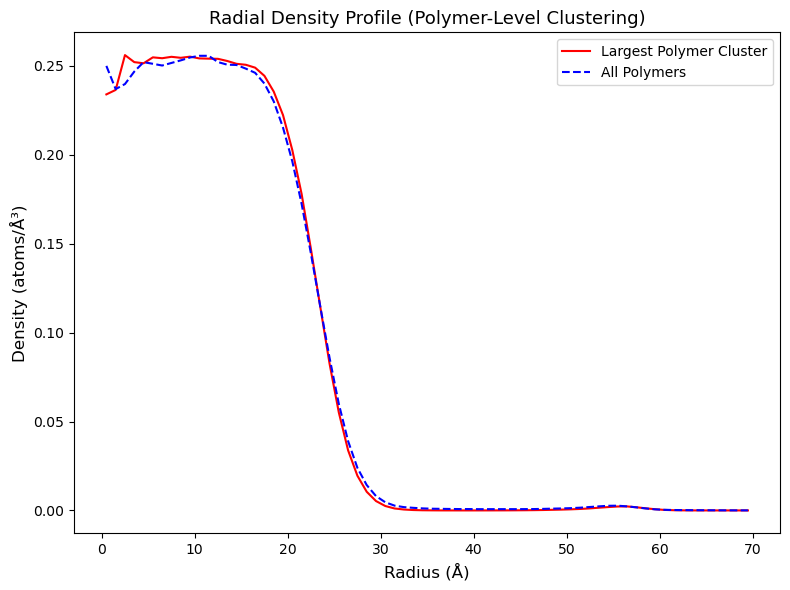

In [4]:
output_csv = 'polymerA_cluster_analysis_sphere.csv'
output_table_csv = 'polymerA_radial_density_table_sphere.csv'
output_plot = 'radialdensity_polymerA_sphere.png'

from MDAnalysis.lib.distances import distance_array

polymer_typeA = 1
cutoff = 2.5
bin_width = 1.0
max_radius = 40 * math.sqrt(3)

polymers = u.select_atoms(f"type {polymer_typeA}")

#polymer = fragment
fragments = polymers.fragments
n_polymers = len(fragments)

print(f"Total polymers (fragments): {n_polymers}")

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

bins = np.arange(0, max_radius + bin_width, bin_width)
V_r = [(4/3) * np.pi * r**3 for r in bins]
shell_volumes = np.array([V_r[i+1] - V_r[i] for i in range(len(V_r)-1)])
bin_centers = 0.5 * (bins[:-1] + bins[1:])

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
results = []


for ts in u.trajectory[250:399]:

    polymers.wrap(compound='fragments')

    uf = UnionFind(n_polymers)

#polymer polymer neighbor check
    for i in range(n_polymers):
        frag_i = fragments[i]
        for j in range(i+1, n_polymers):
            frag_j = fragments[j]

            dists = distance_array(
                frag_i.positions,
                frag_j.positions,
                box=ts.dimensions
            )

            if np.any(dists <= cutoff):
                uf.union(i, j)

    #Build clusters
    groups = defaultdict(list)
    for i in range(n_polymers):
        groups[uf.find(i)].append(i)

    largest_cluster_polymers = max(groups.values(), key=len)
    largest_cluster_size = len(largest_cluster_polymers)
    fraction = largest_cluster_size / n_polymers

    print(f"Frame {ts.frame}: Largest cluster = {largest_cluster_size} polymers, fraction = {fraction:.3f}")
    results.append([ts.frame, largest_cluster_size, fraction])

    largest_cluster_atoms = mda.AtomGroup(
        np.concatenate([fragments[i].indices for i in largest_cluster_polymers]),
        u
    )

    #cluster
    ref_com_cluster = largest_cluster_atoms.center_of_mass()
    distances_cluster = np.linalg.norm(
        largest_cluster_atoms.positions - ref_com_cluster,
        axis=1
    )
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster

    # all polymers
    ref_com_all = polymers.center_of_mass()
    distances_all = np.linalg.norm(
        polymers.positions - ref_com_all,
        axis=1
    )
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

df = pd.DataFrame(results, columns=["Frame", "LargestClusterSize", "Fraction"])
df.to_csv(output_csv, index=False)

# Use the actual number of frames processed in the loop above,
# instead of a hardcoded frame count, so normalization is always correct
# even if the trajectory slice range changes.
n_frames = len(results)
if n_frames == 0:
    raise RuntimeError('No frames were processed; check the trajectory slice and atom selections.')
radial_density_cluster /= (n_frames * shell_volumes)
radial_density_all /= (n_frames * shell_volumes)

density_df = pd.DataFrame({
    "Radius(Å)": bin_centers,
    "ClusterDensity(atoms/Å³)": radial_density_cluster,
    "AllPolymerDensity(atoms/Å³)": radial_density_all
})
density_df.to_csv(output_table_csv, index=False)

plt.figure(figsize=(8,6))
plt.plot(bin_centers, radial_density_cluster, label="Largest Polymer Cluster", color='r')
plt.plot(bin_centers, radial_density_all, label="All Polymers", color='b', linestyle='--')
plt.xlabel("Radius (Å)", fontsize=12)
plt.ylabel("Density (atoms/Å³)", fontsize=12)
plt.title("Radial Density Profile (Polymer-Level Clustering)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# output_csv = 'polymer_cluster_analysis_sphere.csv'
# output_table_csv = 'polymer_radial_density_table_sphere.csv'
# output_plot = 'radialdensity_polymer_sphere.png'

# polymer_type = 1
# cutoff = 2.5
# bin_width = 1.0

# polymers = u.select_atoms(f"type {polymer_type}")
# total_polymers = len(polymers)

# class UnionFind:
#     def __init__(self, n):
#         self.parent = list(range(n))
#         self.rank = [0]*n

#     def find(self, x):
#         while self.parent[x] != x:
#             self.parent[x] = self.parent[self.parent[x]]
#             x = self.parent[x]
#         return x

#     def union(self, a, b):
#         ra, rb = self.find(a), self.find(b)
#         if ra == rb:
#             return
#         if self.rank[ra] < self.rank[rb]:
#             self.parent[ra] = rb
#         else:
#             self.parent[rb] = ra
#             if self.rank[ra] == self.rank[rb]:
#                 self.rank[ra] += 1

# def get_cell_index(pos, cell_size):
#     return tuple((pos // cell_size).astype(int))

# max_radius = 40 * math.sqrt(3)
# bins = np.arange(0, max_radius + bin_width, bin_width)

# V_r = [(4/3)*math.pi*r**3 for r in bins]
# shell_volumes = np.array([V_r[i+1] - V_r[i] for i in range(len(V_r)-1)])
# bin_centers = 0.5 * (bins[:-1] + bins[1:])

# radial_density_cluster = np.zeros(len(shell_volumes))
# radial_density_all = np.zeros(len(shell_volumes))

# results = []


# for ts in u.trajectory[0:399]:

#     polymers.wrap(compound='fragments')
#     positions = polymers.positions
#     box = ts.dimensions[:3]

#     cell_size = cutoff
#     ncell = (box / cell_size).astype(int)

#     cell_dict = defaultdict(list)
#     for i, pos in enumerate(positions):
#         cell = get_cell_index(pos, cell_size)
#         cell_dict[cell].append(i)

#     neighbor_offsets = [(dx,dy,dz) 
#                         for dx in [-1,0,1]
#                         for dy in [-1,0,1]
#                         for dz in [-1,0,1]]

#     pairs = set()
    
#     for cell, atom_ids in cell_dict.items():
#         for dx,dy,dz in neighbor_offsets:
#             neigh = ((cell[0]+dx) % ncell[0],
#                      (cell[1]+dy) % ncell[1],
#                      (cell[2]+dz) % ncell[2])
    
#             for i in atom_ids:
#                 for j in cell_dict.get(neigh, []):
#                     if i == j:
#                         continue
    
#                     a, b = min(i, j), max(i, j)
    
#                     dx = positions[a][0] - positions[b][0]
#                     dy = positions[a][1] - positions[b][1]
#                     dz = positions[a][2] - positions[b][2]
    
#                     dx -= box[0] * round(dx / box[0])
#                     dy -= box[1] * round(dy / box[1])
#                     dz -= box[2] * round(dz / box[2])
    
#                     if dx*dx + dy*dy + dz*dz <= cutoff*cutoff:
#                         pairs.add((a, b))


#     # Cluster detection 
#     uf = UnionFind(total_polymers)
#     for i, j in pairs:
#         uf.union(i, j)

#     groups = defaultdict(list)
#     for i in range(total_polymers):
#         groups[uf.find(i)].append(i)

#     largest_cluster = max(groups.values(), key=len)
#     fraction = len(largest_cluster) / total_polymers

#     print(f"Frame {ts.frame}: Largest cluster = {len(largest_cluster)} | Fraction = {fraction:.3f}")
#     results.append([ts.frame, len(largest_cluster), fraction])


#     cluster_positions = positions[largest_cluster]
#     ref_com_cluster = cluster_positions.mean(axis=0)

#     hist_cluster = np.zeros(len(bins)-1)
#     for pos in cluster_positions:
#         dx = pos[0] - ref_com_cluster[0]
#         dy = pos[1] - ref_com_cluster[1]
#         dz = pos[2] - ref_com_cluster[2]
#         r = math.sqrt(dx*dx + dy*dy + dz*dz)

#         bin_id = int(r // bin_width)
#         if bin_id < len(hist_cluster):
#             hist_cluster[bin_id] += 1

#     radial_density_cluster += hist_cluster

#     # ---- All polymers ----
#     ref_com_all = polymers.center_of_mass()
#     hist_all = np.zeros(len(bins)-1)

#     for pos in positions:
#         dx = pos[0] - ref_com_all[0]
#         dy = pos[1] - ref_com_all[1]
#         dz = pos[2] - ref_com_all[2]
#         r = math.sqrt(dx*dx + dy*dy + dz*dz)

#         bin_id = int(r // bin_width)
#         if bin_id < len(hist_all):
#             hist_all[bin_id] += 1

#     radial_density_all += hist_all

# df = pd.DataFrame(results, columns=["Frame", "LargestClusterSize", "Fraction"])
# df.to_csv(output_csv, index=False)

# n_frames = len(range(0,399))
# radial_density_cluster /= (n_frames * shell_volumes)
# radial_density_all /= (n_frames * shell_volumes)

# density_df = pd.DataFrame({
#     "Radius(Å)": bin_centers,
#     "ClusterDensity(atoms/Å³)": radial_density_cluster,
#     "AllPolymerDensity(atoms/Å³)": radial_density_all
# })
# density_df.to_csv(output_table_csv, index=False)

# plt.figure(figsize=(8,6))
# plt.plot(bin_centers, radial_density_cluster, label="Largest Polymer Cluster")
# plt.plot(bin_centers, radial_density_all, '--', label="All Polymers")
# plt.xlabel("Radius (Å)")
# plt.ylabel("Density (atoms/Å³)")
# plt.title("Radial Density Profile (Manual Distance)")
# plt.legend()
# plt.tight_layout()
# plt.savefig(output_plot, dpi=300)
# plt.show()


In [6]:
print(df.columns.tolist())

['Frame', 'LargestClusterSize', 'Fraction']
